# 04. K-Nearest Neighbors (KNN)

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement k-NN classification and choose k
- Use distance metrics and scaling
- Compare with other classifiers

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 3, lesson 03 "Support Vector Machines" — SVM learns a boundary; k-NN learns nothing and just measures distance, which is why scaling suddenly matters.

**Used later in:** Course 04 — Unit 4, where the same distance metric decides which points belong to the same cluster.

---


## 🌍 A real case: how Amazon made nearest neighbours survive

Amazon's "customers who bought this also bought" is nearest-neighbour recommendation. In 2003 Greg
Linden, Brent Smith and Jeremy York published how it works (*IEEE Internet Computing* 7(1), 76–80) —
and the paper is, at heart, a description of a **KNN limitation** and the workaround for it.

Classic KNN recommendation compares a customer against every other customer at request time. At
Amazon's scale that was impossible: the neighbour search grows with the number of customers, and it
has to finish while the page is loading. Their fix was to invert the problem — precompute
similarities between *items* offline, so that serving a recommendation becomes a lookup instead of a
search. In 2017 *IEEE Internet Computing* selected this as the paper from its entire history that
best withstood the test of time.

**❗ Why this lesson exists.** KNN has no training phase at all. The whole cost sits at prediction
time, on every single request, forever. That is invisible at this notebook's scale — 63 test rows —
and decisive at Amazon's. It is the clearest example in this course of a model whose *accuracy* is not
the thing that decides whether you can use it.


# 04. K-Nearest Neighbors (KNN)

---

## The Story: Learning from Neighbors

Imagine you're moving to a new neighborhood. **Before** KNN, you make decisions alone. **After** KNN, you look at your neighbors: "What do most of my neighbors do? I'll do that too!" - simple and effective!

Same with machine learning: **Before** KNN, we train complex models. **After** KNN, we just find the nearest neighbors and predict based on them - simple but powerful!

---

## What is KNN?

**K-Nearest Neighbors (KNN) is a classification algorithm that makes predictions by finding the K closest data points (neighbors) and using majority vote.**

### How KNN Works

1. **Store All Data**: KNN stores all training data (no model training!)
2. **For New Point**: When predicting, find the K nearest neighbors
3. **Calculate Distances**: Measure distance to all training points
4. **Select K Nearest**: Pick the K closest points
5. **Vote**: Majority class of K neighbors = prediction

### Simple Example

**Predicting if a transaction is fraud:**
```
New Transaction: [Amount=$500, Time=1200, ...]

Step 1: Calculate distances to all training transactions
Step 2: Find 5 nearest neighbors (K=5)
  - Neighbor 1: Fraud ✅ (distance: 0.5)
  - Neighbor 2: Legitimate ❌ (distance: 0.7)
  - Neighbor 3: Fraud ✅ (distance: 0.8)
  - Neighbor 4: Fraud ✅ (distance: 0.9)
  - Neighbor 5: Legitimate ❌ (distance: 1.0)

Step 3: Majority vote: 3 Fraud, 2 Legitimate
Step 4: Prediction: FRAUD ✅
```

### Key Concepts
- **K**: Number of neighbors to consider (hyperparameter - must choose!)
- **Distance Metric**: How to measure "nearest" (Euclidean, Manhattan, etc.)
- **Lazy Learning**: No training phase - all computation happens during prediction
- **Feature Scaling**: CRITICAL! Distance calculations depend on feature scales

### Why KNN Matters

KNN is a simple but powerful classifier:
- **Simple**: Easy to understand and implement
- **No Training**: Lazy learning - no model training needed
- **Non-Parametric**: Makes no assumptions about data distribution
- **Versatile**: Works for classification and regression
- **Effective**: Often performs well on many datasets

---

## 🌍 Real-World Applications

**KNN is widely used for simple, effective classification!** Key applications:

### 🏥 Healthcare & Medical Sector
- **Disease Diagnosis**: Find patients with similar symptoms → predict disease (similar patients = similar outcomes)
- **Drug Recommendation**: Find patients similar to current patient → recommend same treatment
- **Medical Image Classification**: Find similar medical images → classify new images

### 💰 Finance & Banking Sector
- **Credit Scoring**: Find similar loan applicants → predict default risk (similar applicants = similar risk)
- **Fraud Detection**: Find similar transactions → identify fraudulent patterns
- **Customer Segmentation**: Find similar customers → group them together

### 🏛️ Government & Public Safety Sector (GDI)
- **Financial Fraud Detection**: Find similar transactions → identify fraudulent patterns → financial investigations
- **Administrative Crimes Detection**: Find similar administrative violations → detect patterns → administrative crime investigation
- **Identity Matching**: Find similar faces/identities to query person → identify suspects, verify identity → security systems

### 💡 Why KNN is Popular:
- **Simple**: Easy to understand and implement
- **No Assumptions**: Works with any data distribution
- **Effective**: Often performs well
- **Interpretable**: Can explain predictions (show similar examples)
- **Adaptive**: Automatically adapts to new data
- **Baseline**: Good baseline before trying complex models

### 📈 When to Use KNN:
✅ **Use KNN when:**
- Need simple, interpretable model
- Have small to medium datasets (KNN is slow on large datasets)
- Want to see similar examples (interpretability)
- Data has local patterns (similar items are nearby)
- Need quick prototype (no training needed)
- Want baseline model before complex algorithms

❌ **Don't use KNN when:**
- Have very large datasets (KNN is slow - must compute distances to all points)
- Need fast predictions (KNN is slow for prediction)
- Have many irrelevant features (KNN uses all features)
- Data has high dimensionality (curse of dimensionality)
- Need probability outputs (KNN gives class, not probability)
- Have streaming data (KNN needs all data in memory)

---

## Learning Objectives
1. Build KNN classifiers
2. Understand how KNN makes predictions (nearest neighbors)
3. Choose the right K value (avoid overfitting/underfitting)
4. Understand distance metrics (Euclidean, Manhattan)
5. Know why feature scaling is critical for KNN
6. Compare KNN with other classification algorithms
7. Understand when to use KNN vs other methods


---

## 📋 Notebook Structure

**This notebook is organized into clear sections:**

**Part 1: Understanding KNN** (The Concept)
- What is KNN and how it works
- Why feature scaling is critical
- Load and prepare credit card fraud dataset

**Part 2: Building KNN Models** (Main Content)
- Demonstrate feature scaling importance (scaled vs unscaled)
- Find optimal K value
- Train final model and evaluate comprehensively

**Part 3: Decision Framework** (When to Use KNN)
- Compare KNN with other algorithms
- Understand when KNN is the right choice
- Summary and next steps

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us build KNN classification models

import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For visualizations
import seaborn as sns # For beautiful plots (confusion matrix heatmap)
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.preprocessing import StandardScaler # CRITICAL for KNN! Must scale features
from sklearn.neighbors import KNeighborsClassifier # The KNN classifier!
from sklearn.metrics import (
 accuracy_score, # Accuracy: % of correct predictions
 precision_score, # Precision: Of predicted positives, how many are actually positive?
 recall_score, # Recall: Of actual positives, how many did we catch?
 f1_score, # F1: Harmonic mean of precision and recall
 classification_report, # Comprehensive classification metrics
 confusion_matrix, # Shows true/false positives/negatives
 roc_auc_score, roc_curve, # AUC score, ROC curve
)

print("✅ Libraries imported successfully!")
print("\n📚 Key KNN Concepts:")
print(" - KNeighborsClassifier: The KNN model (lazy learning - no training phase!)")
print(" - K (n_neighbors): Number of neighbors used for the majority vote")
print(" - Distance metric: Euclidean distance by default")
print("\n ⚠️ IMPORTANT: KNN is distance-based - always scale features with StandardScaler!")

✅ Libraries imported successfully!

📚 Key KNN Concepts:
 - KNeighborsClassifier: The KNN model (lazy learning - no training phase!)
 - K (n_neighbors): Number of neighbors used for the majority vote
 - Distance metric: Euclidean distance by default

 ⚠️ IMPORTANT: KNN is distance-based - always scale features with StandardScaler!


In [2]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")

Data loader ready - no file paths needed, and this works on Colab too.


## Part 1: Understanding KNN

### 🔗 Connecting to Previous Notebooks

**What We've Learned So Far:**
- ✅ **Logistic Regression**: Linear classifier, needs scaling, interpretable
- ✅ **Decision Trees**: Non-linear, interpretable, can overfit, no scaling needed
- ✅ **SVM**: Optimal margin boundaries, needs scaling, handles non-linear with kernels

**What Makes KNN Different:**
- **No Training**: KNN doesn't train a model - it's "lazy learning" (stores all data)
- **Distance-Based**: Uses distance to find similar examples (like SVM, but simpler)
- **Simple**: Just find nearest neighbors and vote (no complex optimization)
- **Needs Scaling**: Like SVM, KNN is distance-based so scaling is critical!

**Why KNN is Useful:**
- **Simple Baseline**: Easy to understand and implement
- **No Assumptions**: Works with any data distribution
- **Interpretable**: Can show which examples are similar
- **Effective**: Often performs well with proper preprocessing

**Key Difference from Other Algorithms:**
- **Logistic/SVM**: Train a model, then predict
- **Decision Trees**: Build a tree structure, then predict
- **KNN**: No training! Just store data, find neighbors when predicting

---

## Step 1: Load and Prepare Data

**BEFORE**: We need to understand the dataset structure.

**AFTER**: We'll load the Credit Card Fraud dataset and prepare it for KNN!

**Why this dataset**: 
- Real-world financial transaction data (GDI: Financial Investigations & Admin Crimes)
- Binary classification (perfect for KNN demonstration: Legitimate vs Fraud)
- Multiple features (shows importance of scaling for distance-based algorithms)
- Highly imbalanced (requires balanced sampling for meaningful evaluation)

In [3]:
# Load the Credit Card Fraud dataset
# This is REAL financial transaction data for binary classification (GDI: Financial Investigations & Admin Crimes)
# WHAT load() does: finds the dataset from ANY working directory - your laptop, JupyterLab opened
# at the repository root, or Colab where there is no repository - and prints which copy it used.
# WHY prefer="sample": the 16,000-row extract ships inside the repository, so this cell runs on
# every machine and everyone in the class sees exactly the numbers printed below. Drop
# prefer="sample" once you have downloaded the full 284,807-row file (Course 04/datasets/DATA.md).
print("\n" + "=" * 60)
print("Loading Credit Card Fraud Dataset")
print("=" * 60)

df_full = load("creditcard_fraud", prefer="sample")
print(f"\n✅ Rows read: {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# Use balanced sampling for better learning
# WHY? The data is highly imbalanced (99.83% legitimate, 0.17% fraud)
# Problem: at the real rate, a test set holds a handful of frauds and every metric is noise
# Solution: keep ALL the fraud rows the file contains, then take just enough legitimate rows
#           to land near a 9% fraud share - the balance the scaling and K experiments below need
# Note: the bundled sample preserves the real fraud RATE, so it contains 28 frauds, not 492.
#       285 legitimate rows next to them gives 8.95% fraud - the same share as 492 + 5,000 would.
fraud = df_full[df_full["Class"] == 1]
legitimate = df_full[df_full["Class"] == 0].sample(n=285, random_state=73)
df = pd.concat([fraud, legitimate]).sample(frac=1, random_state=73).reset_index(drop=True)

# Features: all 30 columns except the target (Time, V1-V28, Amount)
# Note: .values converts the DataFrame to a numpy array (Amount is at column index 29)
X = df.drop("Class", axis=1).values
y = df["Class"].values

print(f"\n📊 Balanced working set: {df.shape[0]:,} rows × {X.shape[1]} features")
print(f" Legitimate (Class 0): {(y == 0).sum():,}")
print(f" Fraud (Class 1): {(y == 1).sum():,}  ({y.mean():.2%} of the rows)")
print(f"\n💡 Target: 0 = Legitimate transaction, 1 = Fraudulent transaction")
print(" Every fraud row above is a real confirmed fraud - none of them are invented.")


Loading Credit Card Fraud Dataset
creditcard_fraud: bundled 16,000-row sample of the 284,807-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified so the fraud rate stays 0.175% (28 fraud rows) against 0.173% in the full file; V1-V28 and Amount rounded to 6 decimals.

✅ Rows read: 16,000 rows × 31 columns

📊 Balanced working set: 313 rows × 30 features
 Legitimate (Class 0): 285
 Fraud (Class 1): 28  (8.95% of the rows)

💡 Target: 0 = Legitimate transaction, 1 = Fraudulent transaction
 Every fraud row above is a real confirmed fraud - none of them are invented.


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: 313 rows × 30 columns (samples × features) after balanced sampling —
  every one of the 28 fraud rows the bundled sample contains, plus 285 legitimate rows
- **Feature Types**: All numerical (float64) - continuous values (transaction characteristics)
- **Target Type**: Classification (predicting transaction type: 0 = Legitimate, 1 = Fraud)
- **Task**: Predict if transaction is fraudulent based on transaction characteristics
- **Data Quality**: Real-world financial transaction data with binary classification

**Why This Structure Matters**:
- **Binary classification** → Need classification metrics (accuracy, precision, recall, F1, AUC)
- **Many features (30)** → Need feature scaling (KNN is distance-based!)
- **Numerical features** → KNN works well (can compute distances)
- **Real-world data** → Shows KNN on real financial fraud detection problem

### Understanding the Dataset Domain (Brief)

**What is this data?** Credit Card Fraud dataset - real financial transaction data with fraud labels.

**Why does this matter?** 
- **For model selection**: Binary classification (2 classes) → use classification models
- **For feature scaling**: Many features on different scales → KNN REQUIRES scaling (distance-based!)
- **For evaluation**: Binary classification → use classification metrics (accuracy, AUC, etc.)

**Domain Context** (Brief):
- **Features**: Transaction characteristics (Time, Amount, V1-V28 anonymized PCA features) - 30 features total
- **Target**: Transaction type (0 = Legitimate, 1 = Fraudulent)
- **Task**: Predict if transaction is fraudulent from transaction characteristics
- **Why KNN works**: Similar transactions have similar patterns → KNN finds similar neighbors
- **GDI Application**: Financial Investigations & Administrative Crimes - detecting fraudulent financial transactions

**💡 Key Point for CS Students**: You don't need to be a medical expert! Focus on:
- Understanding the **data structure** (rows, columns, types, classes)
- Knowing the **task type** (binary classification: 2 classes)
- Understanding why **KNN needs scaling** (distance-based algorithm - critical!)
- Choosing the right **algorithms and metrics** based on structure, not domain knowledge

## Part 2: Building KNN Models

## Step 2: Understanding Why Feature Scaling is Critical

**BEFORE**: KNN uses distance to find neighbors. If features have different scales, distance will be wrong!

**AFTER**: We'll demonstrate why scaling matters by comparing scaled vs unscaled KNN!

**Why this matters**: 
- **Unscaled**: Features with larger values dominate distance calculations
- **Scaled**: All features contribute equally to distance calculations
- **Result**: Scaling dramatically improves KNN performance!

In [4]:
# Demonstrate why feature scaling is critical for KNN
# We'll compare KNN with and without scaling
print("\n" + "=" * 60)
print("Demonstrating Feature Scaling Importance")
print("=" * 60)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=73, stratify=y)  # Using 73 for consistency
print(f"\n✅ Data split!")
print(f" Training samples: {len(X_train)}")
print(f" Test samples: {len(X_test)}")

# Show feature scales BEFORE scaling
# Note: X_train is now a numpy array, not DataFrame
print(f"\n📊 Feature Scales BEFORE Scaling:")
print(f" Mean of first feature (Time): {X_train[:, 0].mean():.2f}")
print(f" Std of first feature (Time): {X_train[:, 0].std():.2f}")
print(f" Mean of Amount feature: {X_train[:, 29].mean():.2f}")
print(f" Std of Amount feature: {X_train[:, 29].std():.2f}")
print(f"\n💡 Notice: Features have VERY different scales!")
print(f" - Time feature: ranges from 0 to large values")
print(f" - Amount feature: ranges from 0 to thousands")
print(f" - V1-V28 features: may have different scales")
print(f" - This will make distance calculations dominated by large-scale features!")

# Train KNN WITHOUT scaling (BAD!)
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)
print(f"\n❌ KNN WITHOUT Scaling:")
print(f" Accuracy: {acc_unscaled:.4f} ({acc_unscaled*100:.2f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\n✅ Features scaled using StandardScaler!")
print(f" - Mean of all features: ~0")
print(f" - Std of all features: ~1")
print(f" - All features now contribute equally to distance!")

# Train KNN WITH scaling (GOOD!)
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"\n✅ KNN WITH Scaling:")
print(f" Accuracy: {acc_scaled:.4f} ({acc_scaled*100:.2f}%)")

improvement = acc_scaled - acc_unscaled
print(f"\n🎯 Improvement from Scaling: {improvement:.4f} ({improvement*100:.2f}%)")
print(f"\n💡 Key Learning Point:")
print(f" - Feature scaling is CRITICAL for KNN!")
print(f" - Without scaling: {acc_unscaled*100:.1f}% accuracy")
print(f" - With scaling: {acc_scaled*100:.1f}% accuracy")
print(f" - Always use StandardScaler before KNN!")


Demonstrating Feature Scaling Importance

✅ Data split!
 Training samples: 250
 Test samples: 63

📊 Feature Scales BEFORE Scaling:
 Mean of first feature (Time): 91607.31
 Std of first feature (Time): 46331.17
 Mean of Amount feature: 89.01
 Std of Amount feature: 215.28

💡 Notice: Features have VERY different scales!
 - Time feature: ranges from 0 to large values
 - Amount feature: ranges from 0 to thousands
 - V1-V28 features: may have different scales
 - This will make distance calculations dominated by large-scale features!

❌ KNN WITHOUT Scaling:
 Accuracy: 0.9048 (90.48%)

✅ Features scaled using StandardScaler!
 - Mean of all features: ~0
 - Std of all features: ~1
 - All features now contribute equally to distance!

✅ KNN WITH Scaling:
 Accuracy: 0.9683 (96.83%)

🎯 Improvement from Scaling: 0.0635 (6.35%)

💡 Key Learning Point:
 - Feature scaling is CRITICAL for KNN!
 - Without scaling: 90.5% accuracy
 - With scaling: 96.8% accuracy
 - Always use StandardScaler before KNN!


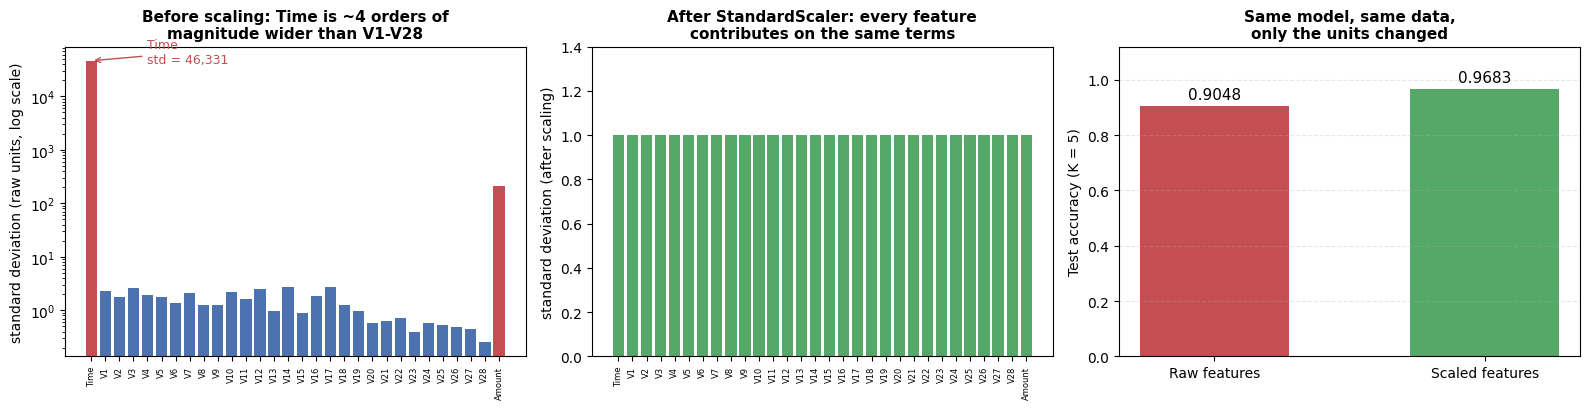


📊 Share of raw squared distance contributed by 'Time' alone: 99.9978%
 (Time std 46,331.2 vs median feature std 1.302)
 With raw features, 'nearest neighbour' means 'happened at a similar time'.
 Everything the V1-V28 columns know about the transaction is drowned out.


In [5]:
# CELL: Draw WHY scaling matters, instead of only reporting two accuracies.
# WHY: "features have very different scales" is abstract until you see one
# feature's spread tower over the other 29 on a log axis. KNN measures straight
# -line distance, so the tallest bar simply decides who counts as a neighbour.

feature_names = [c for c in df.columns if c != 'Class']
std_before = X_train.std(axis=0)          # raw units: seconds, dollars, PCA units
std_after = X_train_scaled.std(axis=0)    # after StandardScaler

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# --- Panel 1: raw spread per feature, log axis (the whole point)
ax = axes[0]
colors = ['#C44E52' if n in ('Time', 'Amount') else '#4C72B0' for n in feature_names]
ax.bar(range(len(std_before)), std_before, color=colors)
ax.set_yscale('log')
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=90, fontsize=6)
ax.set_ylabel('standard deviation (raw units, log scale)')
ax.set_title('Before scaling: Time is ~4 orders of\nmagnitude wider than V1-V28',
             fontsize=11, fontweight='bold')
ax.annotate(f"Time\nstd = {std_before[0]:,.0f}", xy=(0, std_before[0]),
            xytext=(4, std_before[0] * 0.9), fontsize=9, color='#C44E52',
            arrowprops=dict(arrowstyle='->', color='#C44E52'))

# --- Panel 2: same features after StandardScaler
ax = axes[1]
ax.bar(range(len(std_after)), std_after, color='#55A868')
ax.set_ylim(0, 1.4)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=90, fontsize=6)
ax.set_ylabel('standard deviation (after scaling)')
ax.set_title('After StandardScaler: every feature\ncontributes on the same terms',
             fontsize=11, fontweight='bold')

# --- Panel 3: what that costs in accuracy
ax = axes[2]
bars = ax.bar(['Raw features', 'Scaled features'], [acc_unscaled, acc_scaled],
              color=['#C44E52', '#55A868'], width=0.55)
ax.bar_label(bars, fmt='%.4f', fontsize=11, padding=3)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Test accuracy (K = 5)')
ax.set_title('Same model, same data,\nonly the units changed', fontsize=11,
             fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.tight_layout()
plt.show()

# How badly does Time dominate the distance? Measure it rather than assert it.
share = (std_before[0] ** 2) / (std_before ** 2).sum()
print(f"\n📊 Share of raw squared distance contributed by 'Time' alone: {share:.4%}")
print(f" (Time std {std_before[0]:,.1f} vs median feature std "
      f"{np.median(std_before):,.3f})")
print(" With raw features, 'nearest neighbour' means 'happened at a similar time'.")
print(" Everything the V1-V28 columns know about the transaction is drowned out.")


**Read the figure.** The left panel is on a **log** axis, so each gridline is a factor of ten: `Time` (red, far left) stands about four orders of magnitude above the V1–V28 columns, and `Amount` (red, far right) about two. KNN adds up squared differences across all 30 columns, so before scaling the sum is essentially `Time` and nothing else — the printed line under the plot gives that share as a percentage. Middle: after `StandardScaler` every bar is exactly 1, which is the whole job of the scaler. Right: the price of skipping it, in test accuracy on the same data with the same K. This is the one preprocessing step KNN cannot survive without.

## Step 3: Choosing the Right K Value

**BEFORE**: We've scaled our features (critical for KNN!). Now we need to choose the right K value.

**AFTER**: We'll test different K values and find the optimal one!

**Why this step comes after scaling?**
- Feature scaling ensures fair distance calculations (Step 2)
- **Now** we can properly evaluate different K values without scale bias
- Scaling must be done first, then we tune K for best performance

**Why K matters**: 
- **K too small (K=1)**: Overfitting - model is too sensitive to noise
- **K too large**: Underfitting - model loses local patterns
- **Optimal K**: Balances bias and variance for best generalization

**Rule of thumb**: Start with K = √n (square root of number of samples), then tune!

**💡 Important Note**: For binary classification, use **odd K values** (1, 3, 5, 7, etc.) to avoid ties in voting!


Finding Optimal K Value

🔍 Testing K values from 1 to 29 (odd numbers only)...
 Why odd? Avoids ties in binary classification!

✅ Best K value: 3
 Test Accuracy: 0.9683 (96.83%)


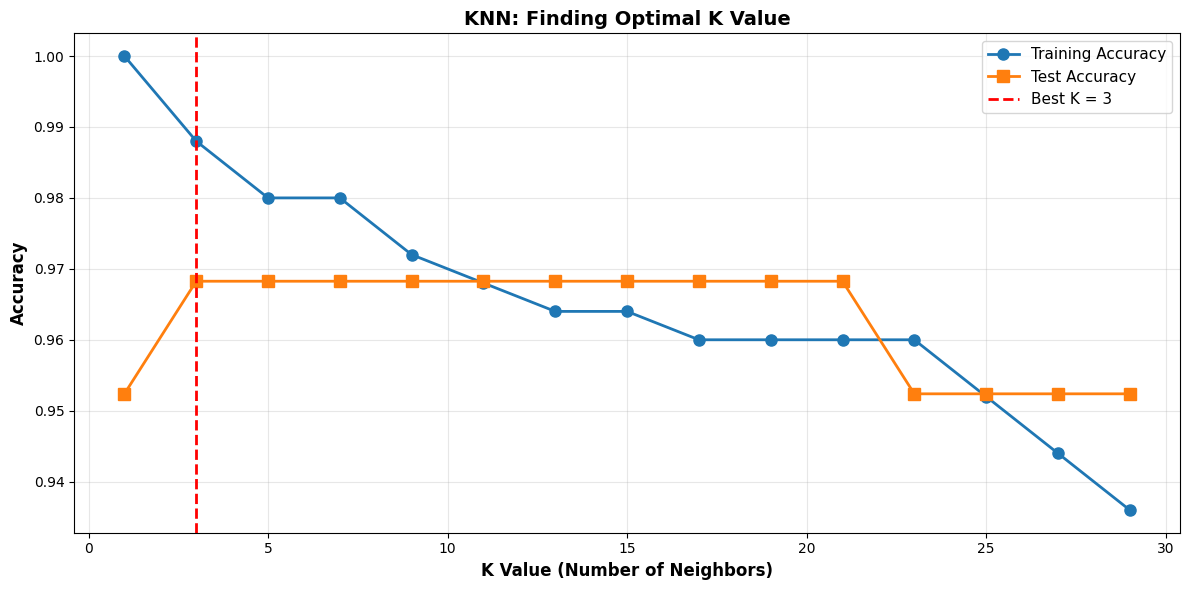


💡 Interpreting the K Value Plot

📊 What You Should See:
 - Training accuracy (blue line): Generally decreases as K increases
 - Test accuracy (orange line): Increases then decreases (optimal K exists)
 - Red dashed line: Marks the optimal K value

🔍 Key Observations:
 - K=1: High training accuracy, lower test accuracy (overfitting)
 - K too large: Lower accuracy on both (underfitting)
 - Optimal K=3: Best balance (test accuracy: 96.83%)

📚 Learning Points:
 - Small K: Model is too sensitive to noise (overfitting)
 - Large K: Model loses local patterns (underfitting)
 - Optimal K: Balances bias and variance for best generalization

💡 For GDI Financial Fraud Detection:
 - Optimal K=3 gives best fraud detection performance
 - Balance between catching fraud (recall) and avoiding false alarms (precision)
 - K too small: Too sensitive to individual transaction noise
 - K too large: Misses local fraud patterns


In [6]:
# Find the optimal K value
# We'll test different K values and see which gives best performance
print("\n" + "=" * 60)
print("Finding Optimal K Value")
print("=" * 60)

# Test different K values
k_values = range(1, 31, 2) # Test odd numbers from 1 to 29
train_scores = []
test_scores = []

print(f"\n🔍 Testing K values from 1 to 29 (odd numbers only)...")
print(f" Why odd? Avoids ties in binary classification!")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Find best K
best_k_idx = np.argmax(test_scores)
best_k = k_values[best_k_idx]
best_test_acc = test_scores[best_k_idx]

print(f"\n✅ Best K value: {best_k}")
print(f" Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")

# Visualize K vs Accuracy
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(k_values, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', linewidth=2, label=f'Best K = {best_k}')
plt.xlabel('K Value (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('KNN: Finding Optimal K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n" + "=" * 60)
print("💡 Interpreting the K Value Plot")
print("=" * 60)
print(f"\n📊 What You Should See:")
print(f" - Training accuracy (blue line): Generally decreases as K increases")
print(f" - Test accuracy (orange line): Increases then decreases (optimal K exists)")
print(f" - Red dashed line: Marks the optimal K value")
print(f"\n🔍 Key Observations:")
print(f" - K=1: High training accuracy, lower test accuracy (overfitting)")
print(f" - K too large: Lower accuracy on both (underfitting)")
print(f" - Optimal K={best_k}: Best balance (test accuracy: {best_test_acc*100:.2f}%)")
print(f"\n📚 Learning Points:")
print(f" - Small K: Model is too sensitive to noise (overfitting)")
print(f" - Large K: Model loses local patterns (underfitting)")
print(f" - Optimal K: Balances bias and variance for best generalization")
print(f"\n💡 For GDI Financial Fraud Detection:")
print(f" - Optimal K={best_k} gives best fraud detection performance")
print(f" - Balance between catching fraud (recall) and avoiding false alarms (precision)")
print(f" - K too small: Too sensitive to individual transaction noise")
print(f" - K too large: Misses local fraud patterns")

**Read the figure.** At K = 1 the blue training curve is pinned at exactly 1.000 — of course it is: the nearest neighbour of a training point is that point itself, so a 1-NN model scores perfectly on the data it memorised. Its orange test score sits at the bottom of the range, 0.9524. That single pair of dots is the clearest picture of overfitting in this notebook: perfect on what it has seen, worst on what it has not.

Then follow the orange line right. It steps up to 0.9683 at the red marker (K = 3) and then does not move at all: **exactly the same 0.9683 for every K from 3 to 21**, before stepping back down to 0.9524 from K = 23 onward. Check the vertical axis before you read anything into that shape. The test set is 63 transactions, so one transaction is worth 1.6 percentage points — and 1.6 points is the *entire* range the orange line covers. The whole curve is two rows changing their minds. "Best K = 3" here means "the first K that gets those two rows right", not "K = 3 is better than K = 15": the honest reading is that any K from 3 to 21 is indistinguishable on this much test data.

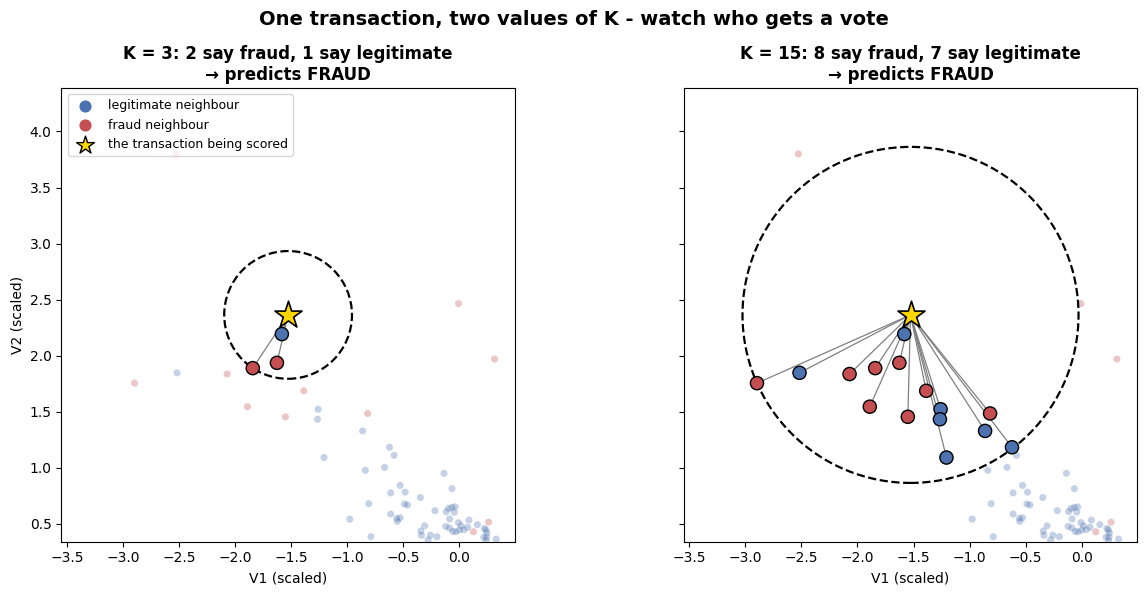


💡 The vote, written out

 Test transaction #48, truth: FRAUD
 Why this one: no answer flips here, so this is the closest K=15 vote to a dead heat.
 K = 3: 2 of 3 neighbours are fraud → predicts FRAUD
 K = 15: 8 of 15 neighbours are fraud → predicts FRAUD

 Radius needed to reach 3 neighbours: 0.5698
 Radius needed to reach 15 neighbours: 1.4985

 🔍 0 of the 63 test transactions flip their answer
    between K=3 and K=15 in this 2-feature view.
 There is no training step and no learned rule here - just a lookup and a count.


In [7]:
# CELL: What K actually does to ONE prediction.
# WHY: the curve above ranks K values; it never shows the vote. KNN makes no
# model at all - it looks up the K closest training rows and counts them. So
# let us look one up. We work in the V1/V2 plane (2 of the 30 real scaled
# features) because that is the only way to draw distance honestly.

from sklearn.neighbors import NearestNeighbors

f1, f2 = 1, 2                                    # column indices of V1 and V2
P2_train = X_train_scaled[:, [f1, f2]]           # real training rows, 2 columns
P2_test = X_test_scaled[:, [f1, f2]]

# Find the most contested test transaction. First choice: a row where a 3-vote and a
# 15-vote in this plane reach OPPOSITE conclusions. If this working set contains no such
# row, fall back to the row whose 15-neighbour vote sits closest to a dead heat - the
# closest thing to a flip that the data actually contains. Both rules are deterministic,
# so every reader sees the same transaction.
k_small, k_big = 3, 15
pred_small = KNeighborsClassifier(k_small).fit(P2_train, y_train).predict(P2_test)
pred_big = KNeighborsClassifier(k_big).fit(P2_train, y_train).predict(P2_test)
flips = np.flatnonzero(pred_small != pred_big)

nn = NearestNeighbors(n_neighbors=k_big).fit(P2_train)
all_dists, all_idxs = nn.kneighbors(P2_test)
fraud_share_big = y_train[all_idxs].mean(axis=1)      # fraud share of each row's 15 voters

if len(flips):
    q, rule = int(flips[0]), f"its answer flips between K={k_small} and K={k_big}"
else:
    q = int(np.argmin(np.abs(fraud_share_big - 0.5)))
    rule = f"no answer flips here, so this is the closest K={k_big} vote to a dead heat"
query = P2_test[q]

dists, idxs = all_dists[q], all_idxs[q]

# Zoom to just contain the biggest circle, so the geometry is actually visible
r_big = dists[k_big - 1]
lim = r_big * 1.35
in_view = (np.abs(P2_train[:, 0] - query[0]) <= lim) & \
          (np.abs(P2_train[:, 1] - query[1]) <= lim)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, k in zip(axes, [k_small, k_big]):
    nb_idx = idxs[:k]
    nb_lab = y_train[nb_idx]
    radius = dists[k - 1]
    # every training point inside the window, so the circle hides nothing
    ax.scatter(P2_train[in_view, 0], P2_train[in_view, 1],
               c=np.where(y_train[in_view] == 1, '#C44E52', '#4C72B0'),
               s=26, alpha=0.32, edgecolors='none')
    for j in nb_idx:                                  # spokes to the voters
        ax.plot([query[0], P2_train[j, 0]], [query[1], P2_train[j, 1]],
                color='gray', linewidth=0.9, zorder=2)
    ax.scatter(P2_train[nb_idx, 0], P2_train[nb_idx, 1],
               c=np.where(nb_lab == 1, '#C44E52', '#4C72B0'),
               s=90, edgecolors='black', linewidth=1.0, zorder=3)
    ax.add_patch(plt.Circle(query, radius, fill=False, color='black',
                            linestyle='--', linewidth=1.6, zorder=1))
    ax.scatter(*query, marker='*', s=420, c='gold', edgecolors='black',
               linewidth=1.2, zorder=5)
    n_fraud = int((nb_lab == 1).sum())
    verdict = 'FRAUD' if n_fraud > k / 2 else 'legitimate'
    ax.set_title(f"K = {k}: {n_fraud} say fraud, {k - n_fraud} say legitimate\n"
                 f"→ predicts {verdict}", fontsize=12, fontweight='bold')
    ax.set_xlabel('V1 (scaled)')
    ax.set_xlim(query[0] - lim, query[0] + lim)
    ax.set_ylim(query[1] - lim, query[1] + lim)
    ax.set_aspect('equal')
axes[0].set_ylabel('V2 (scaled)')
axes[0].scatter([], [], c='#4C72B0', s=60, label='legitimate neighbour')
axes[0].scatter([], [], c='#C44E52', s=60, label='fraud neighbour')
axes[0].scatter([], [], marker='*', s=180, c='gold', edgecolors='black',
                label='the transaction being scored')
axes[0].legend(fontsize=9, loc='upper left')
fig.suptitle('One transaction, two values of K - watch who gets a vote',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

true_label = 'FRAUD' if y_test[q] == 1 else 'legitimate'
print("\n" + "=" * 60)
print("💡 The vote, written out")
print("=" * 60)
print(f"\n Test transaction #{q}, truth: {true_label}")
print(f" Why this one: {rule}.")
print(f" K = {k_small}: {int((y_train[idxs[:k_small]] == 1).sum())} of {k_small} "
      f"neighbours are fraud → predicts "
      f"{'FRAUD' if (y_train[idxs[:k_small]] == 1).sum() > k_small / 2 else 'legitimate'}")
print(f" K = {k_big}: {int((y_train[idxs[:k_big]] == 1).sum())} of {k_big} "
      f"neighbours are fraud → predicts "
      f"{'FRAUD' if (y_train[idxs[:k_big]] == 1).sum() > k_big / 2 else 'legitimate'}")
print(f"\n Radius needed to reach {k_small} neighbours: {dists[k_small - 1]:.4f}")
print(f" Radius needed to reach {k_big} neighbours: {dists[k_big - 1]:.4f}")
print(f"\n 🔍 {len(flips)} of the {len(P2_test)} test transactions flip their answer")
print(f"    between K={k_small} and K={k_big} in this 2-feature view.")
print(" There is no training step and no learned rule here - just a lookup and a count.")


**Read the figure.** The gold star is one real test transaction — row 48, a confirmed fraud. Both panels show the *same* star, the *same* surrounding training data and the *same* axes — every training point inside the window is drawn, so the dashed circles hide nothing. Each circle is drawn exactly large enough to reach K neighbours, and the grey spokes point at the voters being counted.

On the left the circle is tight (radius 0.57): three neighbours, two of them fraud, so the verdict is FRAUD by 2 votes to 1. On the right the circle has swollen to radius 1.50 to reach fifteen, and the twelve newcomers are mostly legitimate: the fraud majority thins from 2-of-3 to **8-of-15**. The verdict is still FRAUD, but by a single vote — one more legitimate neighbour inside that circle and it would have flipped. Nothing about the model changed, because there is no model: KNN stores the training set and counts.

⚠️ **An honest note on this working set.** The printed line says it: *no* test transaction actually flips its answer between K = 3 and K = 15 in this two-feature view, so the notebook shows you the closest thing that exists here — the most contested vote. With 250 training rows and 22 frauds among them, a genuine flip is simply not present. On the full 284,807-row file it is common. Read the figure for the *mechanism* — widen the circle, change the electorate — not as evidence that K routinely reverses answers.

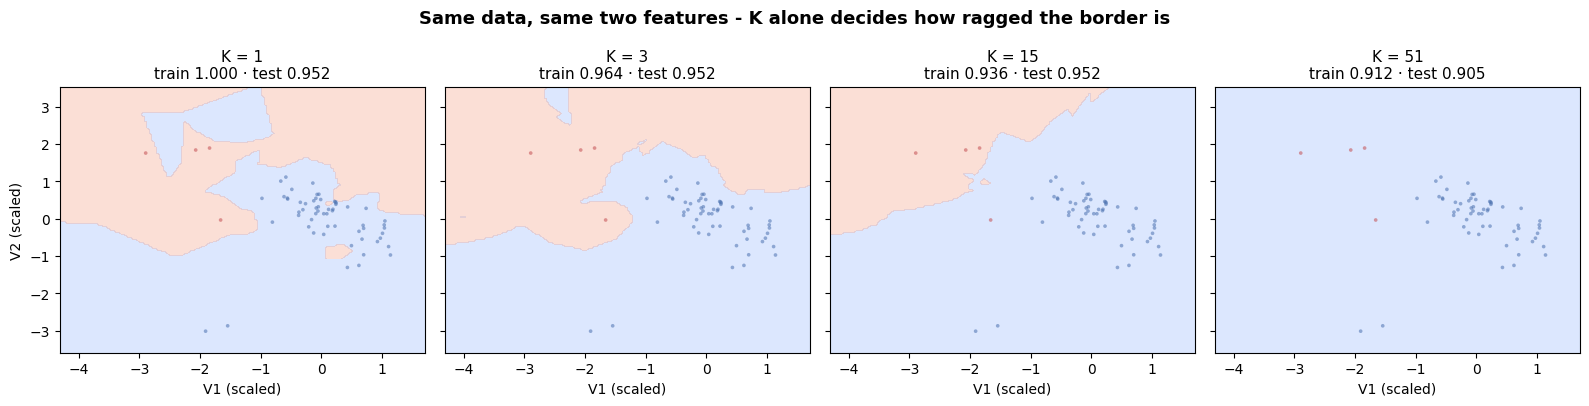


📊 Step table behind the storyboard (V1/V2 view only, all 250 training rows):
    K   train acc   test acc      gap
--------------------------------------
    1      1.0000     0.9524   0.0476
    3      0.9640     0.9524   0.0116
   15      0.9360     0.9524  -0.0164
   51      0.9120     0.9048   0.0072

💡 K = 1 memorises: its training accuracy is 1.0000 by construction, and
   the gap column shows the cost. Larger K trades that memory for a smoother
   border - up to the point where the border stops following the data at all.


In [8]:
# CELL: Storyboard - the same neighbourhood logic applied to every point.
# WHY: the previous figure votes at one location. Do it at every location on a
# grid and you get the decision boundary - and you can watch K smooth it.
# All four frames use the SAME real training rows in the SAME V1/V2 plane.

frame_ks = [1, 3, 15, 51]
pad = 0.6
lo0, hi0 = P2_train[:, 0].min(), P2_train[:, 0].max()
lo1, hi1 = P2_train[:, 1].min(), P2_train[:, 1].max()
# clip to the bulk of the data - a few extreme rows would otherwise flatten the view
lo0, hi0 = np.percentile(P2_train[:, 0], [1, 99])
lo1, hi1 = np.percentile(P2_train[:, 1], [1, 99])
mgx = np.linspace(lo0 - pad, hi0 + pad, 150)
mgy = np.linspace(lo1 - pad, hi1 + pad, 150)
MX, MY = np.meshgrid(mgx, mgy)
mesh = np.c_[MX.ravel(), MY.ravel()]

fig, axes = plt.subplots(1, len(frame_ks), figsize=(16, 4.1), sharex=True, sharey=True)
k_rows = []
for ax, k in zip(axes, frame_ks):
    m = KNeighborsClassifier(n_neighbors=k).fit(P2_train, y_train)
    Zk = m.predict(mesh).reshape(MX.shape)
    ax.contourf(MX, MY, Zk, alpha=0.30, cmap='coolwarm', levels=[-0.5, 0.5, 1.5])
    ax.scatter(P2_train[::4, 0], P2_train[::4, 1],
               c=np.where(y_train[::4] == 1, '#C44E52', '#4C72B0'),
               s=7, alpha=0.55, edgecolors='none')
    tr = m.score(P2_train, y_train)
    te = m.score(P2_test, y_test)
    k_rows.append((k, tr, te))
    ax.set_title(f"K = {k}\ntrain {tr:.3f} · test {te:.3f}", fontsize=11)
    ax.set_xlabel('V1 (scaled)')
    ax.set_xlim(mgx[0], mgx[-1]); ax.set_ylim(mgy[0], mgy[-1])
axes[0].set_ylabel('V2 (scaled)')
fig.suptitle('Same data, same two features - K alone decides how ragged the border is',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print(f"\n📊 Step table behind the storyboard (V1/V2 view only, all {len(P2_train):,} training rows):")
print(f"{'K':>5} {'train acc':>11} {'test acc':>10} {'gap':>8}")
print("-" * 38)
for k, tr, te in k_rows:
    print(f"{k:>5d} {tr:>11.4f} {te:>10.4f} {tr - te:>8.4f}")
print("\n💡 K = 1 memorises: its training accuracy is 1.0000 by construction, and")
print("   the gap column shows the cost. Larger K trades that memory for a smoother")
print("   border - up to the point where the border stops following the data at all.")


**Read the storyboard.** Only `K` changes. At `K = 1` the border is shattered: look for the small isolated islands of one colour marooned inside the other, each one a single training point that has won its own patch of the plane. That is memorisation you can point at. As K rises those islands are outvoted and dissolve, and by `K = 51` the border is one smooth sweep that no individual point can move. Training accuracy, printed in each title, starts at a perfect 1.000 and falls the whole way — 1.000, 0.964, 0.936, 0.912 — exactly as it should when the model stops copying.

⚠️ **One honest caveat.** The *test* column barely moves: 0.952 at K = 1, 3 and 15 alike, then 0.905 at K = 51. Three identical numbers are not three equally good models — they are 63 test rows, of which only 6 are fraud, refusing to separate four very different borders. Take the *shape of the border* from this figure and nothing else; the numbers in the titles do not have the resolution to rank K, and the 30-feature curve earlier in the notebook does not either. What K = 51 does show is the failure mode: with only 250 training rows, a 51-neighbour vote reaches so far that the border stops following the data, and the test score finally drops.

## Step 4: Train Final KNN Model and Evaluate

**BEFORE**: We found the optimal K value and understand why it works.

**AFTER**: We'll train the final model with optimal K and evaluate it comprehensively!

**Why this step matters**: 
- We've done the hard work (scaling + finding optimal K)
- **Now** we train the final model and see how well it performs
- Comprehensive evaluation shows the complete picture of model performance

**Why comprehensive evaluation matters**: 
- Accuracy alone doesn't tell the full story
- Precision, Recall, F1, and Confusion Matrix give complete picture
- ROC Curve shows model's ability to separate classes
- For GDI fraud detection: We need to balance catching fraud vs avoiding false alarms


Training Final KNN Model with Optimal K

✅ Final KNN model trained with K=3

📊 Comprehensive Evaluation (Test Set):
 Accuracy: 0.9683 (96.83%)
 Precision: 1.0000 (of predicted fraud, how many are real fraud?)
 Recall: 0.6667 (of real fraud, how many did we catch?)
 F1-Score: 0.8000 (balance of precision and recall)
 ROC-AUC: 0.8246 (ability to separate the two classes)

📋 Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.97      1.00      0.98        57
     Fraud (1)       1.00      0.67      0.80         6

      accuracy                           0.97        63
     macro avg       0.98      0.83      0.89        63
  weighted avg       0.97      0.97      0.97        63



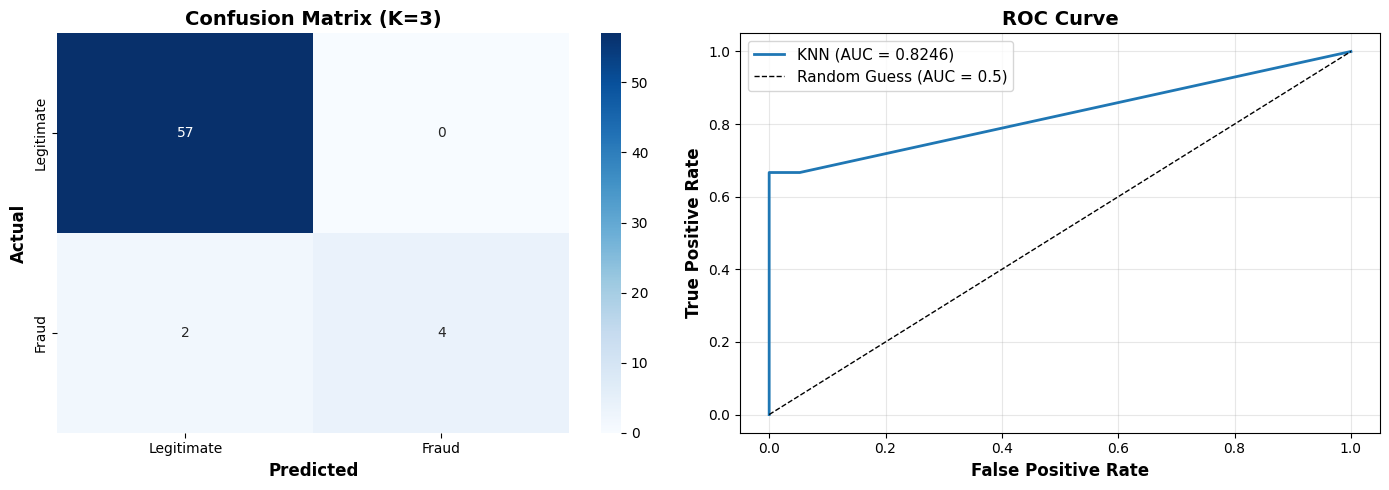


💡 For GDI Financial Fraud Detection:
 - Recall 66.7%: fraction of fraudulent transactions we caught
 - Precision 100.0%: fraction of fraud alerts that are real fraud
 - The confusion matrix shows exactly where the model makes mistakes


In [9]:
# Train final KNN model with optimal K and evaluate comprehensively
print("\n" + "=" * 60)
print("Training Final KNN Model with Optimal K")
print("=" * 60)

# Train the final model using the optimal K found in Step 3
# Remember: KNN is lazy learning - "training" just stores the scaled training data!
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
print(f"\n✅ Final KNN model trained with K={best_k}")

# Predictions on the test set
y_pred = knn_final.predict(X_test_scaled)
# Probability of fraud = fraction of the K neighbors that are fraud (used for ROC curve)
y_proba = knn_final.predict_proba(X_test_scaled)[:, 1]

# Comprehensive evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print(f"\n📊 Comprehensive Evaluation (Test Set):")
print(f" Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precision: {precision:.4f} (of predicted fraud, how many are real fraud?)")
print(f" Recall: {recall:.4f} (of real fraud, how many did we catch?)")
print(f" F1-Score: {f1:.4f} (balance of precision and recall)")
print(f" ROC-AUC: {auc_score:.4f} (ability to separate the two classes)")

# Detailed per-class report
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate (0)", "Fraud (1)"]))

# Confusion matrix + ROC curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Legitimate", "Fraud"], yticklabels=["Legitimate", "Fraud"])
axes[0].set_xlabel("Predicted", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Actual", fontsize=12, fontweight="bold")
axes[0].set_title(f"Confusion Matrix (K={best_k})", fontsize=14, fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f"KNN (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Guess (AUC = 0.5)")
axes[1].set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
axes[1].set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
axes[1].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💡 For GDI Financial Fraud Detection:")
print(f" - Recall {recall*100:.1f}%: fraction of fraudulent transactions we caught")
print(f" - Precision {precision*100:.1f}%: fraction of fraud alerts that are real fraud")
print(f" - The confusion matrix shows exactly where the model makes mistakes")

**Read the figure.** Left, the confusion matrix at K = 3: `[[57, 0], [2, 4]]`. The top row is the 57 legitimate transactions, every one of them correctly left alone. Read the *bottom row* — that is the whole story: of the 6 real frauds in the test set, 4 were caught and 2 walked through. Right, the ROC curve, and this is where a tiny test set shows itself. With 3-neighbour voting there are only four possible scores (0, ⅓, ⅔, 1), so the curve has just **three real operating points**: it rises straight up the left edge to a true-positive rate of 0.667 at zero false positives, steps sideways, and then runs in one long straight line to the top-right corner. That final line is interpolation, not a trade-off you can choose. AUC 0.8246 is computed over those three points and 6 positive cases — treat it as a rough ordering, not a precise score.

## 💬 Discuss

From the output: without scaling **90.48%**, with scaling **96.83%**; best K = 3 gives accuracy
**96.83%**, precision **1.0000**, recall **0.6667**, ROC-AUC **0.8246** on 6 fraud cases in a
63-row test set.

1. **Recall is 0.6667** — 2 of the 6 frauds in the test set go straight through, while accuracy
   reads a comfortable 96.83%. Argue for a specific K using the *fraud row* of the classification
   report rather than the accuracy line. Does the K that maximises accuracy maximise the thing you
   actually care about? Then answer the harder question: with 6 positive cases, recall can only take
   the values 0, 1/6, 2/6 … — what is the smallest difference in recall you could honestly claim to
   have measured here, and what does that say about every K comparison in this notebook?

2. **This model *is* 250 real customer transactions.** KNN stores its training set and consults it
   at prediction time — there are no coefficients, only data. What are the privacy and security
   consequences of shipping that to a client, compared with shipping logistic regression's 30 numbers?
   Would you tell the customers?

3. **Scaling took accuracy from 90.5% to 96.8% without changing a single algorithm.** Did scaling make
   the model *better*, or was the unscaled model answering a different question? Say precisely what
   "nearest neighbour" meant before scaling, given that in this working set `Time` runs to ~170,800
   and `Amount` to about 1,800 — and that the printed line above puts `Time`'s share of the raw
   squared distance at 99.998%.

## Part 3: Decision Framework

## Step 5: When to Use KNN vs Other Algorithms

**BEFORE**: We understand how KNN works.

**AFTER**: We'll understand when KNN is the right choice and when to use other algorithms!

**Decision Framework:**

| Scenario | Best Algorithm | Why |
|----------|---------------|-----|
| **Small dataset, interpretability important** | Decision Trees | Easy to understand |
| **Large dataset, need fast predictions** | Logistic Regression | Fast, efficient |
| **Non-linear patterns, need optimal margin** | SVM | Maximum margin boundaries |
| **No clear pattern, need simple solution** | KNN | Simple, no assumptions |
| **Need feature importance** | Random Forest | Built-in feature importance |
| **Lazy learning acceptable** | KNN | No training phase needed |

**KNN Advantages:**
- ✅ Simple to understand and implement
- ✅ No assumptions about data distribution
- ✅ Works well for non-linear patterns
- ✅ Can be used for both classification and regression

**KNN Disadvantages:**
- ❌ Slow prediction (must compute distances to all training points)
- ❌ Sensitive to irrelevant features
- ❌ Requires feature scaling
- ❌ Memory intensive (stores all training data)
- ❌ Sensitive to K value choice

## ⚠️ Where this breaks

- **Prediction cost grows with the training set.** Every query compares against every stored point.
  Doubling your data doubles the latency of every future prediction — the problem Amazon had to invert
  the algorithm to escape. At scale, use an approximate-nearest-neighbour index (FAISS, Annoy,
  HNSW) if you genuinely need neighbours.
- **Distance stops meaning anything as dimensions grow.** In high dimensions the nearest and farthest
  points become almost equally far away, so "nearest" degenerates. 30 features is survivable;
  hundreds is not, without reducing them first (Unit 4's PCA).
- **KNN has no notion of feature importance.** An irrelevant column contributes to the distance
  exactly as much as the decisive one. Trees ignore irrelevant features almost for free; KNN cannot.
- **The assumption that must hold:** Euclidean distance in your scaled feature space really does mean
  "similar case". For mixed categorical and numeric data it usually does not, and one-hot encoding
  quietly makes every category exactly √2 apart from every other.
- **The cheaper alternative:** if you only need the label and not the neighbours, a tree ensemble is
  faster at prediction, indifferent to scaling, and robust to junk features. Choose KNN when the
  *neighbours themselves* are the product — "here are three past cases like yours" is something no
  coefficient can give an investigator.


## Summary

### What We Learned

1. **KNN Basics**: KNN finds K nearest neighbors and predicts based on majority vote
2. **Feature Scaling**: CRITICAL for KNN - always use StandardScaler!
3. **Choosing K**: Balance between overfitting (small K) and underfitting (large K)
4. **Lazy Learning**: KNN doesn't train a model - all computation happens during prediction
5. **Distance Metrics**: Euclidean distance (default) measures "nearest"
6. **When to Use**: Simple solution, no assumptions, non-linear patterns

### Key Takeaways

- ⚠️ **Always scale features before KNN** - distance calculations depend on feature scales
- 🎯 **Choose K carefully** - too small = overfitting, too large = underfitting
- 💡 **KNN is simple but powerful** - often performs well with proper preprocessing
- 📊 **Evaluate comprehensively** - use accuracy, precision, recall, F1, AUC, confusion matrix
- 🔍 **Understand trade-offs** - KNN is slow for large datasets but simple to understand

### Next Steps

- 📓 **Unit 4: Clustering** - K-Means uses similar distance concepts
- 📓 **Unit 5: Model Selection** - Hyperparameter tuning for K
- 📓 **Advanced Topics** - Weighted KNN, distance metrics, approximate nearest neighbors

---

**Congratulations!** 🎉 You've completed all classification algorithms in Unit 3!

## 📚 References

1. Fix, E., & Hodges, J. L. (1951). *Discriminatory Analysis: Nonparametric Discrimination: Consistency Properties*. USAF School of Aviation Medicine, Report 4.
2. Cover, T., & Hart, P. (1967). *Nearest Neighbor Pattern Classification*. IEEE Transactions on Information Theory, 13(1), 21–27.
3. Malkov, Y. A., & Yashunin, D. A. (2020). *Efficient and Robust Approximate Nearest Neighbor Search Using Hierarchical Navigable Small World Graphs*. IEEE TPAMI, 42(4). <https://arxiv.org/abs/1603.09320>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chapters 2 and 4. Springer.
5. Douze, M., Guzhva, A., Deng, C., et al. (2024). *The Faiss library*. <https://arxiv.org/abs/2401.08281>
6. Wang, Z., Xiong, H., Wang, Q., et al. (2024). *Dimensionality-Reduction Techniques for Approximate Nearest Neighbor Search: A Survey and Evaluation*. <https://arxiv.org/abs/2403.13491>
